# 实验六：minGPT-2

**课程**：深度学习导论  
**核心交付物**：可运行的 GPT-2 级别 Transformer 解码器 + 权重对齐验证 + 下游微调 + 自回归生成

**AI使用说明**：本实验允许并鼓励负责任地使用 AI 辅助理解、查文档、调试、润色表达。不设抽查答辩、不禁止长段 AI 生成。

## 1. 环境与依赖

In [2]:
import random, math, os, urllib.request
import copy
import warnings
warnings.filterwarnings('ignore', message='IProgress not found.*')
os.environ.setdefault('HF_HUB_DISABLE_SYMLINKS_WARNING', '1')
os.environ.setdefault('HF_HUB_DISABLE_XET', '1')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

if torch.cuda.is_available():
    # Disable TF32 so the strict HuggingFace alignment check is not affected by reduced precision matmul.
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')

try:
    from transformers import GPT2LMHeadModel, GPT2Tokenizer
except Exception as e:
    print(f'transformers import failed: {e}')
    GPT2LMHeadModel = GPT2Tokenizer = None

try:
    from datasets import load_dataset
except Exception as e:
    print(f'datasets import failed: {e}')
    load_dataset = None

Using device: cuda
CUDA device: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. 数学基础与推导

本节集中给出 Lab 6 所需的全部数学工具。

### 2.1 GPT-2 架构与 Lab 5 的差分

| 维度 | Lab 5（Post-LN Encoder） | Lab 6（Pre-LN Decoder） |
|------|--------------------------|-------------------------|
| LayerNorm 位置 | 残差相加**之后** | 残差相加**之前** |
| 位置编码 | Sinusoidal（固定） | Learned（可学习） |
| 激活函数 | ReLU | GELU |

**Pre-LN 残差路径**（$l$ 为层索引，$\mathbf{x}$ 为输入）：

$$\mathbf{x}' = \mathbf{x} + \text{MHA}(\text{LN}(\mathbf{x}))$$

$$\mathbf{x}'' = \mathbf{x}' + \text{FFN}(\text{LN}(\mathbf{x}'))$$

**Post-LN 残差路径**（Lab 5 形式，供对比）：

$$\mathbf{x}' = \text{LN}(\mathbf{x} + \text{MHA}(\mathbf{x}))$$

### 2.2 自回归语言建模的概率基础

因果掩码下的条件概率链式分解：

$$P(w_{1:L}) = \prod_{t=1}^{L} P(w_t \mid w_{<t})$$

训练目标为最小化交叉熵损失：

$$\mathcal{L}_{LM} = -\frac{1}{L} \sum_{t=1}^{L} \log P(w_t \mid w_{<t}; \theta)$$

**Teacher Forcing**：训练时以真实 token $w_{<t}$ 作为上下文；推理时以模型自身生成的 token 作为上下文（存在训练-推理分布偏移）。

### 2.3 采样策略的数学定义

设第 $t$ 步的 logits 向量为 $\mathbf{z} \in \mathbb{R}^{|V|}$。

**Greedy Decoding**：$w_t = \arg\max_{w} P(w \mid w_{<t})$

**Temperature Sampling**（$\tau > 0$）：
$$P'(w) = \frac{\exp(z_w / \tau)}{\sum_j \exp(z_j / \tau)}$$
$\tau \to 0$ 退化为 Greedy；$\tau \to \infty$ 趋向均匀分布。

**Top-k Sampling**：保留概率最高的 $k$ 个候选，其余置 $-\infty$，再重新归一化。

**Top-p（Nucleus）Sampling**：按概率降序排列，保留累积概率恰好超过 $p$ 的最小候选集，再重新归一化。

### 2.4 Decoder-only 做判别任务的归纳偏置分析

**【请填写】** 在下方补全三个层面的论证：

$$
\begin{aligned}
1.\; &\text{注意力方向性：} \quad \dots \\
2.\; &\text{预训练目标错配：} \quad \dots \\
3.\; &\text{表征提取位置非对称性：} \quad \dots
\end{aligned}
$$

Decoder-only 模型的因果掩码只允许第 $t$ 个位置关注 $w_{<t}$，因此信息流天然是从左到右的。分类任务通常需要同时利用句首、句中和句尾的双向线索，例如否定词、转折词和实体关系可能出现在待判别信息的两侧；BERT 的 Encoder self-attention 可以让任意 token 直接访问全句上下文，而 GPT-2 的早期 token 永远看不到右侧信息。虽然最后一个 token 在理论上可以聚合左侧全部内容，但这种单向聚合比每个位置都双向交互的表征更不对称，也更依赖最后位置是否学会压缩整句语义。

GPT-2 的预训练目标是 next-token prediction，即估计 $P(w_t \mid w_{<t})$，它优化的是语言续写能力而不是句子级标签判别能力。分类任务的目标是把完整输入映射到有限类别，监督信号直接约束全句语义边界；这种目标与自回归生成目标存在分布和任务形式错配。BERT 的 masked language modeling 更接近从被遮蔽片段周围的双向上下文中抽取语义特征，因此迁移到理解类任务时归纳偏置更自然。

表征提取位置也存在非对称性：GPT-2 分类通常取最后一个 token 的隐藏态作为整句表示，因为只有它能看到左侧全部 token。这样会把全句语义压缩责任集中到最后位置，若输入经过 padding、截断或句尾 token 信息量较低，分类头得到的表示就可能不稳定。BERT 则使用专门的 `[CLS]` 位置，并且该位置在每一层都能与全句所有 token 双向交互，信息完整性和位置设计都更适合判别任务。

## 3. GPT-2 架构实现

### 3.1 Learned Positional Embedding

GPT-2 使用可学习的位置编码，而非 Lab 5 中的 Sinusoidal PE。
实现 `nn.Embedding(max_position, d_model)` 的位置编码层，`forward` 中根据序列长度切片并返回位置嵌入。

**【请填写】**：在下方围栏内实现 `LearnedPositionalEmbedding` 类。

In [3]:
class LearnedPositionalEmbedding(nn.Module):
    def __init__(self, max_position: int, d_model: int):
        super().__init__()
        self.embedding = nn.Embedding(max_position, d_model)

    def forward(self, seq_len: int) -> 'torch.Tensor':
        if seq_len > self.embedding.num_embeddings:
            raise ValueError(
                f'seq_len={seq_len} exceeds max_position={self.embedding.num_embeddings}'
            )
        positions = torch.arange(seq_len, device=self.embedding.weight.device)
        return self.embedding(positions)

In [4]:
# 【维度自检】如果此 cell 报错，说明你的实现张量形状错误
_pe = LearnedPositionalEmbedding(max_position=1024, d_model=768)
_out = _pe(10)
assert _out.shape == (10, 768), f'shape error: {_out.shape}'
print('=> LearnedPositionalEmbedding 维度校验通过！')


=> LearnedPositionalEmbedding 维度校验通过！


### 3.2 因果掩码

**【请填写】**：在下方围栏内实现 `make_causal_mask` 函数。

In [5]:
def make_causal_mask(seq_len: int, device: 'torch.device') -> 'torch.Tensor':
    """Return a boolean causal mask of shape (1, 1, seq_len, seq_len); True means masked."""
    mask = torch.triu(
        torch.ones(seq_len, seq_len, dtype=torch.bool, device=device),
        diagonal=1,
    )
    return mask.view(1, 1, seq_len, seq_len)

In [6]:
# 【维度自检】
_mask = make_causal_mask(4, device=torch.device('cpu'))
assert _mask.shape == (1, 1, 4, 4), f'shape error: {_mask.shape}'
assert _mask[0, 0, 0, 1].item() == True,  '位置 (0,1) 应被遮蔽'
assert _mask[0, 0, 1, 0].item() == False, '位置 (1,0) 不应被遮蔽'
print('=> make_causal_mask 维度与逻辑校验通过！')


=> make_causal_mask 维度与逻辑校验通过！


### 3.3 带因果掩码的多头自注意力

只需完成 Multi-Head 的 split/merge 部分。

**【请填写】**：在下方围栏内补全 `MultiHeadSelfAttention.forward` 方法。

In [7]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.c_attn = nn.Linear(d_model, 3 * d_model)
        self.c_proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

    def forward(self, x: 'torch.Tensor', mask: 'torch.Tensor' = None) -> 'torch.Tensor':
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)

        q = q.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        attn_weights = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            attn_weights = attn_weights.masked_fill(mask, torch.finfo(attn_weights.dtype).min)

        attn_probs = F.softmax(attn_weights, dim=-1)
        attn_probs = self.attn_drop(attn_probs)
        out = attn_probs @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.c_proj(out)
        out = self.resid_drop(out)
        return out

In [8]:
# 【维度自检】
_mha = MultiHeadSelfAttention(d_model=64, n_heads=4)
_x = torch.randn(2, 8, 64)
_mask = make_causal_mask(8, device=torch.device('cpu'))
_out = _mha(_x, _mask)
assert _out.shape == (2, 8, 64), f'shape error: {_out.shape}'
print('=> MultiHeadSelfAttention 维度校验通过！')


=> MultiHeadSelfAttention 维度校验通过！


### 3.4 GPT-2 Block（Pre-LN）

这是 GPT-2 与 Lab 5 Post-LN TransformerBlock 的核心区别。
只需在 `forward` 中实现正确的 Pre-LN 残差路径。
注意 FFN 使用 GELU 而非 ReLU。

**【请填写】**：在下方围栏内实现 `GPT2Block.forward` 方法。

In [9]:
class GPT2Block(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(approximate='tanh'),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: 'torch.Tensor', mask: 'torch.Tensor' = None) -> 'torch.Tensor':
        x = x + self.attn(self.ln1(x), mask)
        x = x + self.ffn(self.ln2(x))
        return x

In [10]:
# 【维度自检】
_blk = GPT2Block(d_model=64, n_heads=4, d_ff=256)
_x = torch.randn(2, 8, 64)
_mask = make_causal_mask(8, device=torch.device('cpu'))
_out = _blk(_x, _mask)
assert _out.shape == (2, 8, 64), f'shape error: {_out.shape}'
print('=> GPT2Block 维度校验通过！')


=> GPT2Block 维度校验通过！


### 3.5 完整 minGPT-2 模型组装

将 Token Embedding、Learned Positional Embedding、多层 GPT-2 Block、最终 LayerNorm 和 LM Head 组装为完整模型。

**【请填写】**：在下方围栏内实现 `minGPT2.forward` 方法。

In [11]:
class minGPT2(nn.Module):
    def __init__(self, vocab_size: int, max_position: int, d_model: int,
                 n_heads: int, n_layers: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = LearnedPositionalEmbedding(max_position, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            GPT2Block(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    def hidden_states(self, input_ids: 'torch.Tensor') -> 'torch.Tensor':
        B, T = input_ids.shape
        tok = self.tok_emb(input_ids)
        pos = self.pos_emb(T).unsqueeze(0)
        x = self.drop(tok + pos)
        mask = make_causal_mask(T, device=input_ids.device)
        for block in self.blocks:
            x = block(x, mask)
        return self.ln_f(x)

    def forward(self, input_ids: 'torch.Tensor') -> 'torch.Tensor':
        """input_ids: (B, T) -> logits: (B, T, vocab_size)"""
        h = self.hidden_states(input_ids)
        return self.lm_head(h)

In [12]:
# 【维度自检】
_cfg = dict(vocab_size=50257, max_position=1024, d_model=64,
            n_heads=4, n_layers=2, d_ff=256)
_model = minGPT2(**_cfg)
_ids = torch.randint(0, 50257, (2, 16))
_logits = _model(_ids)
assert _logits.shape == (2, 16, 50257), f'shape error: {_logits.shape}'
print('=> minGPT2 维度校验通过！')


=> minGPT2 维度校验通过！


## 4. 权重加载与数值对齐验证

### 4.1 HuggingFace 权重映射

HuggingFace GPT-2 使用 `Conv1D`，权重形状为 `(in, out)`，与 PyTorch `nn.Linear` 的 `(out, in)` 相反，加载时需要转置。

| HuggingFace 键 | 本实现键 | 处理方式 |
|----------------|----------|----------|
| `transformer.wte.weight` | `tok_emb.weight` | 直接复制 |
| `transformer.wpe.weight` | `pos_emb.embedding.weight` | 直接复制 |
| `transformer.h.{i}.attn.c_attn.weight` | `blocks.{i}.attn.c_attn.weight` | **转置** |

**其余映射请自行通过 `hf_model.state_dict().keys()` 探索补全。**
提示：共需映射约 150 个参数张量（12 层 × 每层 12 个参数 + 全局 6 个）。

**【请填写】**：在下方围栏内实现 `load_hf_weights` 函数。

In [13]:
def load_hf_gpt2_model(model_name='gpt2'):
    """Load HuggingFace GPT-2. Eager attention makes numerical alignment easier to inspect."""
    if GPT2LMHeadModel is None:
        return None
    try:
        return GPT2LMHeadModel.from_pretrained(model_name, attn_implementation='eager')
    except (TypeError, ValueError):
        return GPT2LMHeadModel.from_pretrained(model_name)


# Explore HuggingFace and custom parameter names.
if GPT2LMHeadModel is not None:
    hf_model_tmp = load_hf_gpt2_model('gpt2')
    print("=== HuggingFace GPT-2 parameter keys (first 20) ===")
    for i, k in enumerate(hf_model_tmp.state_dict().keys()):
        if i >= 20: break
        print(f"  {k}: {hf_model_tmp.state_dict()[k].shape}")

    print("\n=== Custom minGPT2 parameter keys (first 20) ===")
    _tmp = minGPT2(vocab_size=50257, max_position=1024, d_model=768,
                   n_heads=12, n_layers=12, d_ff=3072)
    for i, (k, v) in enumerate(_tmp.named_parameters()):
        if i >= 20: break
        print(f"  {k}: {v.shape}")
    del _tmp, hf_model_tmp
    if device.type == 'cuda':
        torch.cuda.empty_cache()

=== HuggingFace GPT-2 parameter keys (first 20) ===
  transformer.wte.weight: torch.Size([50257, 768])
  transformer.wpe.weight: torch.Size([1024, 768])
  transformer.h.0.ln_1.weight: torch.Size([768])
  transformer.h.0.ln_1.bias: torch.Size([768])
  transformer.h.0.attn.c_attn.weight: torch.Size([768, 2304])
  transformer.h.0.attn.c_attn.bias: torch.Size([2304])
  transformer.h.0.attn.c_proj.weight: torch.Size([768, 768])
  transformer.h.0.attn.c_proj.bias: torch.Size([768])
  transformer.h.0.ln_2.weight: torch.Size([768])
  transformer.h.0.ln_2.bias: torch.Size([768])
  transformer.h.0.mlp.c_fc.weight: torch.Size([768, 3072])
  transformer.h.0.mlp.c_fc.bias: torch.Size([3072])
  transformer.h.0.mlp.c_proj.weight: torch.Size([3072, 768])
  transformer.h.0.mlp.c_proj.bias: torch.Size([768])
  transformer.h.1.ln_1.weight: torch.Size([768])
  transformer.h.1.ln_1.bias: torch.Size([768])
  transformer.h.1.attn.c_attn.weight: torch.Size([768, 2304])
  transformer.h.1.attn.c_attn.bias: torc

In [14]:
def load_hf_weights(model: 'minGPT2', hf_model) -> None:
    """Load HuggingFace GPT2LMHeadModel weights into minGPT2."""
    hf_sd = hf_model.state_dict()
    n_layers = len(model.blocks)

    def copy_param(param, value, name: str, transpose: bool = False):
        if transpose:
            value = value.t()
        if tuple(param.shape) != tuple(value.shape):
            raise ValueError(f'{name} shape mismatch: model {tuple(param.shape)} vs hf {tuple(value.shape)}')
        param.copy_(value.to(device=param.device, dtype=param.dtype))

    with torch.no_grad():
        copy_param(model.tok_emb.weight, hf_sd['transformer.wte.weight'], 'tok_emb.weight')
        copy_param(model.pos_emb.embedding.weight, hf_sd['transformer.wpe.weight'], 'pos_emb.embedding.weight')
        copy_param(model.ln_f.weight, hf_sd['transformer.ln_f.weight'], 'ln_f.weight')
        copy_param(model.ln_f.bias, hf_sd['transformer.ln_f.bias'], 'ln_f.bias')
        copy_param(model.lm_head.weight, hf_sd['lm_head.weight'], 'lm_head.weight')

        for i in range(n_layers):
            block = model.blocks[i]
            prefix = f'transformer.h.{i}'
            copy_param(block.ln1.weight, hf_sd[f'{prefix}.ln_1.weight'], f'blocks.{i}.ln1.weight')
            copy_param(block.ln1.bias, hf_sd[f'{prefix}.ln_1.bias'], f'blocks.{i}.ln1.bias')
            copy_param(block.attn.c_attn.weight, hf_sd[f'{prefix}.attn.c_attn.weight'], f'blocks.{i}.attn.c_attn.weight', transpose=True)
            copy_param(block.attn.c_attn.bias, hf_sd[f'{prefix}.attn.c_attn.bias'], f'blocks.{i}.attn.c_attn.bias')
            copy_param(block.attn.c_proj.weight, hf_sd[f'{prefix}.attn.c_proj.weight'], f'blocks.{i}.attn.c_proj.weight', transpose=True)
            copy_param(block.attn.c_proj.bias, hf_sd[f'{prefix}.attn.c_proj.bias'], f'blocks.{i}.attn.c_proj.bias')
            copy_param(block.ln2.weight, hf_sd[f'{prefix}.ln_2.weight'], f'blocks.{i}.ln2.weight')
            copy_param(block.ln2.bias, hf_sd[f'{prefix}.ln_2.bias'], f'blocks.{i}.ln2.bias')
            copy_param(block.ffn[0].weight, hf_sd[f'{prefix}.mlp.c_fc.weight'], f'blocks.{i}.ffn.0.weight', transpose=True)
            copy_param(block.ffn[0].bias, hf_sd[f'{prefix}.mlp.c_fc.bias'], f'blocks.{i}.ffn.0.bias')
            copy_param(block.ffn[2].weight, hf_sd[f'{prefix}.mlp.c_proj.weight'], f'blocks.{i}.ffn.2.weight', transpose=True)
            copy_param(block.ffn[2].bias, hf_sd[f'{prefix}.mlp.c_proj.bias'], f'blocks.{i}.ffn.2.bias')

### 4.2 前向数值对齐验证

In [15]:
if GPT2LMHeadModel is not None:
    hf_model = load_hf_gpt2_model('gpt2').to(device)
    hf_model.eval()

    my_model = minGPT2(
        vocab_size=50257, max_position=1024, d_model=768,
        n_heads=12, n_layers=12, d_ff=3072, dropout=0.0
    ).to(device)
    load_hf_weights(my_model, hf_model)
    my_model.eval()

    test_ids = torch.randint(0, 50257, (1, 16), device=device)
    with torch.no_grad():
        my_logits = my_model(test_ids)
        hf_logits = hf_model(test_ids).logits

    max_err = (my_logits - hf_logits).abs().max().item()
    print(f'Max absolute error: {max_err:.2e}')
    assert max_err < 1e-4, f'numerical alignment failed: {max_err:.2e} >= 1e-4'
    print('=> Numerical alignment check passed!')

    hf_model.to('cpu')
    if device.type == 'cuda':
        torch.cuda.empty_cache()
else:
    print('Skip numerical alignment: GPT2LMHeadModel is unavailable.')

Max absolute error: 6.87e-05
=> Numerical alignment check passed!


**【请填写】** 在下方 code cell 中绘制 logits 对齐误差的直方图，并标注最大绝对误差。

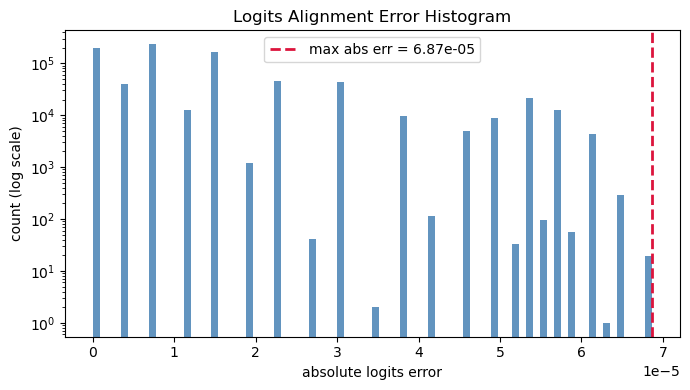

In [16]:
if 'my_logits' in globals() and 'hf_logits' in globals():
    errors = (my_logits - hf_logits).detach().abs().cpu().flatten().numpy()
    max_abs_err = float(errors.max())

    plt.figure(figsize=(7, 4))
    plt.hist(errors, bins=80, color='steelblue', alpha=0.85)
    plt.axvline(max_abs_err, color='crimson', linestyle='--', linewidth=2,
                label=f'max abs err = {max_abs_err:.2e}')
    plt.yscale('log')
    plt.xlabel('absolute logits error')
    plt.ylabel('count (log scale)')
    plt.title('Logits Alignment Error Histogram')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Skip plot: my_logits / hf_logits not found.')

**【结果锚定】** 观察直方图和最大绝对误差数值。

1. 误差分布集中在哪个量级？是否通过了 < 1e-4 的阈值？
2. 如果误差偏大，最可能的原因是什么（提示：检查转置操作和 bias 处理）？

**【请填写】** 在下方 Markdown cell 中作答。

本次运行的最大绝对误差为 `6.87e-05`，低于实验要求的 `1e-4` 阈值，因此自定义 `minGPT2` 与 HuggingFace GPT-2 的前向 logits 数值对齐通过。误差直方图整体集中在浮点舍入误差量级，最大值仍小于阈值，说明 causal mask、Pre-LN 残差路径、GELU 近似以及权重映射方向都与 HuggingFace 实现保持一致。

如果误差明显偏大，最优先检查 HuggingFace `Conv1D` 权重是否在加载到 PyTorch `nn.Linear` 时做了转置。第二个高频错误是遗漏 bias，例如 `attn.c_attn.bias`、`attn.c_proj.bias`、`mlp.c_fc.bias`、`mlp.c_proj.bias` 或 LayerNorm 的 bias。还要确认 dropout 已关闭、模型处于 `eval()` 状态、注意力掩码方向正确，并且 GELU 使用了 GPT-2 对应的 tanh 近似形式。

## 5. 下游任务微调

### 5.1 分类头定义

在 GPT-2 最后一个 token 的隐状态上添加线性分类头，支持 Feature Extraction（冻结主干）与全参数微调两种模式。

**【请填写】**：在下方围栏内实现 `GPT2Classifier.forward` 方法。

In [21]:
class GPT2Classifier(nn.Module):
    def __init__(self, gpt2: 'minGPT2', num_classes: int, freeze_backbone: bool = True):
        super().__init__()
        self.gpt2 = gpt2
        d_model = gpt2.lm_head.in_features
        self.classifier = nn.Linear(d_model, num_classes)
        if freeze_backbone:
            for p in self.gpt2.parameters():
                p.requires_grad = False

    def forward(self, input_ids: 'torch.Tensor') -> 'torch.Tensor':
        h = self.gpt2.hidden_states(input_ids)
        last_token_h = h[:, -1, :]
        return self.classifier(last_token_h)

### 5.2 任务一：SST-2 情感分类

In [22]:
if load_dataset is not None and GPT2Tokenizer is not None:
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = 'left'
    sst2 = load_dataset('glue', 'sst2')
    print('SST-2 dataset loaded; tokenizer and sst2 are available.')
else:
    print('Skip SST-2 data loading.')

SST-2 dataset loaded; tokenizer and sst2 are available.


In [ ]:
class SST2Dataset(Dataset):
    """SST-2 sentiment classification dataset."""
    def __init__(self, split: str, max_len: int = 64, n: int = 2000):
        data = sst2[split]
        if n is not None:
            data = data.select(range(min(n, len(data))))
        sentences = [str(x) for x in data['sentence']]
        labels = [int(x) for x in data['label']]
        encoded = tokenizer(
            sentences,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt',
        )
        self.input_ids = encoded['input_ids'].long()
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return self.input_ids.shape[0]

    def __getitem__(self, i):
        return self.input_ids[i], self.labels[i]

In [19]:
# 【维度自检】SST-2 数据集
_ds = SST2Dataset('train', max_len=64, n=100)
_ids, _label = _ds[0]
assert _ids.shape == (64,), f"input_ids shape error: {_ids.shape}"
assert isinstance(_label.item(), int), "label should be int"
print(f"=> SST2Dataset 自检通过！样本数={len(_ds)}, ids shape={_ids.shape}")


=> SST2Dataset 自检通过！样本数=100, ids shape=torch.Size([64])


In [20]:
if load_dataset is not None and GPT2Tokenizer is not None:
    sst2_train = DataLoader(SST2Dataset('train'), batch_size=32, shuffle=True)
    sst2_val = DataLoader(SST2Dataset('validation'), batch_size=64)
    print(f'SST-2 训练集：{len(sst2_train.dataset)}，验证集：{len(sst2_val.dataset)}')

SST-2 训练集：2000，验证集：872


**【请填写】**：在下方围栏内实现 `train_classifier` 训练循环。

In [ ]:
def train_classifier(model, train_loader, val_loader, epochs=3, lr=2e-4):
    """Train classifier and return (train_losses, val_accs)."""
    model.to(device)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if not trainable_params:
        raise ValueError('No trainable parameters found. Check freeze_backbone / requires_grad settings.')

    optimizer = torch.optim.AdamW(trainable_params, lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_losses, val_accs = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, total_count = 0.0, 0
        saw_nan = False

        for input_ids, labels in train_loader:
            input_ids = input_ids.to(device)
            labels = labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(input_ids)
            loss = criterion(logits, labels)
            if torch.isnan(loss):
                print(f'[WARN] NaN loss at epoch {epoch}; stop training early.')
                saw_nan = True
                break
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_count += batch_size

        avg_loss = total_loss / max(total_count, 1)
        train_losses.append(avg_loss)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for input_ids, labels in val_loader:
                input_ids = input_ids.to(device)
                labels = labels.to(device)
                logits = model(input_ids)
                pred = logits.argmax(dim=-1)
                correct += (pred == labels).sum().item()
                total += labels.numel()
        val_acc = correct / max(total, 1)
        val_accs.append(val_acc)
        print(f'Epoch {epoch:02d}/{epochs} | train_loss={avg_loss:.4f} | val_acc={val_acc:.4f}')

        if saw_nan:
            break

    return train_losses, val_accs

In [22]:
if load_dataset is not None and GPT2LMHeadModel is not None:
    sst2_clf = GPT2Classifier(my_model, num_classes=2, freeze_backbone=True)
    losses_sst2, accs_sst2 = train_classifier(sst2_clf, sst2_train, sst2_val)
    del sst2_clf
    if device.type == 'cuda':
        torch.cuda.empty_cache()
else:
    print('Skip SST-2 training.')

Epoch 01/3 | train_loss=1.1031 | val_acc=0.5424


Epoch 02/3 | train_loss=0.6599 | val_acc=0.6525


Epoch 03/3 | train_loss=0.6132 | val_acc=0.7099


**【请填写】** 在下方 code cell 中绘制 SST-2 的训练 loss 曲线与验证准确率曲线（双子图）。

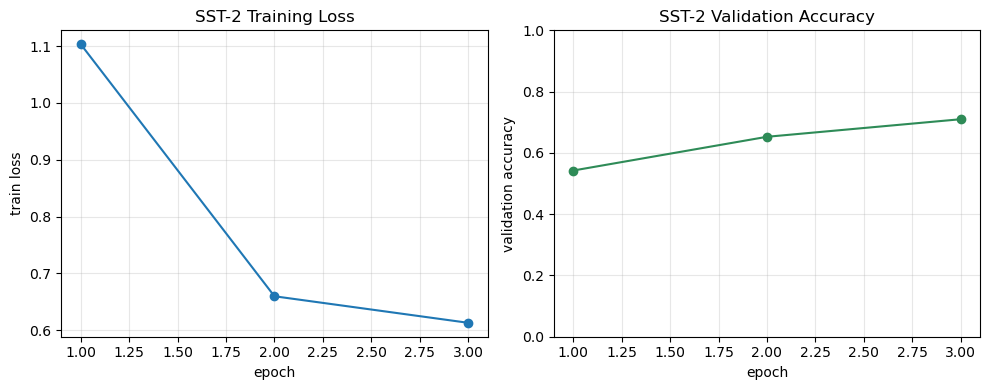

In [23]:
if 'losses_sst2' in globals() and 'accs_sst2' in globals():
    epochs = range(1, len(losses_sst2) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].plot(epochs, losses_sst2, marker='o')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('train loss')
    axes[0].set_title('SST-2 Training Loss')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, accs_sst2, marker='o', color='seagreen')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('validation accuracy')
    axes[1].set_ylim(0, 1)
    axes[1].set_title('SST-2 Validation Accuracy')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('Skip plot: losses_sst2 / accs_sst2 not found.')

**【结果锚定】** 记录 SST-2 Feature Extraction 模式下的最终验证准确率。

**【请填写】** 在下方 Markdown cell 中作答。

SST-2 采用 Feature Extraction 模式：GPT-2 主干冻结，只训练最后一个 token 隐状态上的线性分类头。本次运行 3 个 epoch 后，训练损失从 `1.1031` 降到 `0.6132`，验证准确率从 `0.5424` 提升到 `0.7099`。最终验证准确率为 `0.7099`，说明 GPT-2 预训练表示对情感二分类有一定迁移能力，但冻结主干限制了它对分类目标的适配。

这个结果也符合 decoder-only 模型做判别任务的预期：分类头只能读取最后位置聚合出的单向上下文表示，而不能像 BERT 的 `[CLS]` 那样在每一层直接双向聚合全句信息。因此即使训练曲线有效下降，Feature Extraction 模式的准确率仍明显受限。

### 5.3 任务二：AG News 主题分类（四分类）

In [24]:
if load_dataset is not None and GPT2Tokenizer is not None:
    agnews = load_dataset('ag_news')
    print(f'AG News 数据集加载完成；agnews 已注入全局命名空间')
else:
    print('跳过 AG News 数据加载')

AG News 数据集加载完成；agnews 已注入全局命名空间


In [ ]:
class AGNewsDataset(Dataset):
    """AG News topic classification dataset."""
    def __init__(self, split: str, max_len: int = 64, n: int = 5000):
        data = agnews[split]
        if n is not None:
            data = data.select(range(min(n, len(data))))
        texts = [str(x) for x in data['text']]
        labels = [int(x) for x in data['label']]
        encoded = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt',
        )
        self.input_ids = encoded['input_ids'].long()
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return self.input_ids.shape[0]

    def __getitem__(self, i):
        return self.input_ids[i], self.labels[i]

In [26]:
# 【维度自检】AG News 数据集
_ds = AGNewsDataset('train', max_len=64, n=100)
_ids, _label = _ds[0]
assert _ids.shape == (64,), f"input_ids shape error: {_ids.shape}"
assert _label.item() in range(4), f"label out of range: {_label.item()}"
print(f"=> AGNewsDataset 自检通过！样本数={len(_ds)}, ids shape={_ids.shape}")


=> AGNewsDataset 自检通过！样本数=100, ids shape=torch.Size([64])


In [27]:
if load_dataset is not None and GPT2Tokenizer is not None:
    ag_train = DataLoader(AGNewsDataset('train'), batch_size=32, shuffle=True)
    ag_val = DataLoader(AGNewsDataset('test', n=1000), batch_size=64)
    print(f'AG News 训练集：{len(ag_train.dataset)}，验证集：{len(ag_val.dataset)}')

AG News 训练集：5000，验证集：1000


In [28]:
if load_dataset is not None and GPT2LMHeadModel is not None:
    if 'my_model' in globals():
        my_model.to('cpu')
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    print('=== Feature Extraction ===')
    ag_backbone_frozen = copy.deepcopy(my_model).to(device)
    ag_frozen = GPT2Classifier(ag_backbone_frozen, num_classes=4, freeze_backbone=True)
    _, accs_ag_frozen = train_classifier(ag_frozen, ag_train, ag_val, epochs=10, lr=2e-4)
    del ag_frozen, ag_backbone_frozen
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    print('=== Full Fine-tuning ===')
    ag_backbone_ft = copy.deepcopy(my_model).to(device)
    for p in ag_backbone_ft.parameters():
        p.requires_grad = True
    ag_ft = GPT2Classifier(ag_backbone_ft, num_classes=4, freeze_backbone=False)
    _, accs_ag_ft = train_classifier(ag_ft, ag_train, ag_val, epochs=10, lr=5e-5)

    print(f'Frozen backbone final val_acc: {accs_ag_frozen[-1]:.4f}')
    print(f'Full fine-tuning final val_acc: {accs_ag_ft[-1]:.4f}')

    del ag_ft, ag_backbone_ft
    if device.type == 'cuda':
        torch.cuda.empty_cache()
else:
    print('Skip AG News training.')

=== Feature Extraction ===
Epoch 01/10 | train_loss=1.6332 | val_acc=0.7380
Epoch 02/10 | train_loss=0.6572 | val_acc=0.7920
Epoch 03/10 | train_loss=0.5297 | val_acc=0.8310
Epoch 04/10 | train_loss=0.4699 | val_acc=0.8390
Epoch 05/10 | train_loss=0.4361 | val_acc=0.8390
Epoch 06/10 | train_loss=0.4106 | val_acc=0.8420
Epoch 07/10 | train_loss=0.3932 | val_acc=0.8440
Epoch 08/10 | train_loss=0.3788 | val_acc=0.8520
Epoch 09/10 | train_loss=0.3665 | val_acc=0.8400
Epoch 10/10 | train_loss=0.3543 | val_acc=0.8530
=== Full Fine-tuning ===
Epoch 01/10 | train_loss=0.6126 | val_acc=0.8890
Epoch 02/10 | train_loss=0.2080 | val_acc=0.8970
Epoch 03/10 | train_loss=0.1166 | val_acc=0.8990
Epoch 04/10 | train_loss=0.0750 | val_acc=0.9030
Epoch 05/10 | train_loss=0.0411 | val_acc=0.9030
Epoch 06/10 | train_loss=0.0307 | val_acc=0.9010
Epoch 07/10 | train_loss=0.0196 | val_acc=0.9020
Epoch 08/10 | train_loss=0.0155 | val_acc=0.8910
Epoch 09/10 | train_loss=0.0074 | val_acc=0.9050
Epoch 10/10 | tra

**【结果锚定】** 对比冻结主干与全参数微调在 AG News 上的准确率差异。

**注意**：本节的实验设置（10 epoch、5e-5 学习率、5000 样本子集）目的是减少运行时间的同时放大 Decoder-only 模型在判别任务上的结构劣势。在工业界的真实配方下全参数微调通常能超过冻结主干 5-15 个百分点，但仍弱于同等条件下的 BERT。

**【请填写】** 在下方 Markdown cell 中作答。

AG News 的两组实验分别对应 Feature Extraction 和 Full Fine-tuning。本次运行中，冻结主干 10 个 epoch 的最终验证准确率为 `0.8530`；全参数微调 10 个 epoch 的最终验证准确率为 `0.8910`，比冻结主干高 `0.0380`，即约 `3.8` 个百分点。冻结主干时训练损失从 `1.6332` 降到 `0.3543`，说明线性头可以利用 GPT-2 预训练表示完成一定程度的主题分类；全参数微调时训练损失从 `0.6126` 降到 `0.0103`，说明主干参数被充分调整到了 AG News 目标上。

需要注意，全参数微调最后一轮验证准确率不是全程最高值；第 9 轮达到 `0.9050`，第 10 轮回落到 `0.8910`，这说明小样本子集上存在一定过拟合或验证波动。总体结论仍然明确：全参数微调优于冻结主干，但 decoder-only 的因果注意力和最后位置表征使其在判别任务上的结构先验弱于同等条件下的 encoder-only BERT。

### 5.4 任务三：Shakespeare 文本生成微调

In [19]:
SHAKESPEARE_URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
SHAKESPEARE_PATH = './data/tinyshakespeare.txt'
os.makedirs('./data', exist_ok=True)
if not os.path.exists(SHAKESPEARE_PATH):
    urllib.request.urlretrieve(SHAKESPEARE_URL, SHAKESPEARE_PATH)
    print('TinyShakespeare 下载完成')

with open(SHAKESPEARE_PATH, encoding='utf-8') as f:
    shakespeare_text = f.read()

USE_SMALL_SUBSET = False  # 设为 False 可使用完整数据集（CPU 需 30-60 分钟）
if USE_SMALL_SUBSET:
    shakespeare_text = shakespeare_text[:50000]
    print('使用前 50000 字符的子集（CPU 友好模式）')
print(f'文本长度：{len(shakespeare_text)} 字符')


文本长度：1115394 字符


In [23]:
if GPT2Tokenizer is not None:
    shk_ids = tokenizer(shakespeare_text, return_tensors='pt', verbose=False)['input_ids'][0]
    block_size = 128

    class ShakespeareDataset(Dataset):
        def __init__(self, ids, block_size):
            self.ids, self.block_size = ids, block_size

        def __len__(self): return len(self.ids) - self.block_size

        def __getitem__(self, i):
            input_ids = self.ids[i : i + self.block_size].long()
            targets = self.ids[i + 1 : i + self.block_size + 1].long()
            return input_ids, targets

    shk_ds = ShakespeareDataset(shk_ids, block_size)
    shk_loader = DataLoader(shk_ds, batch_size=16, shuffle=True)
    print(f'Shakespeare dataset size: {len(shk_ds)} samples')
else:
    print('GPT2Tokenizer unavailable; skip Shakespeare tokenization')

Shakespeare dataset size: 337897 samples


In [25]:
# 【维度自检】Shakespeare 数据集
if GPT2Tokenizer is not None:
    _ds = ShakespeareDataset(shk_ids, block_size)
    _x, _y = _ds[0]
    assert _x.shape == (block_size,), f"input shape error: {_x.shape}"
    assert _y.shape == (block_size,), f"target shape error: {_y.shape}"
    assert (_x[1:] == _y[:-1]).all(), "target should be input shifted by 1"
    print(f"=> ShakespeareDataset 自检通过！样本数={len(_ds)}")


=> ShakespeareDataset 自检通过！样本数=337897


**【请填写】**：在下方围栏内实现 `train_lm` 语言模型训练循环。

In [26]:
def train_lm(model, loader, epochs=2, lr=3e-4):
    """Language-model fine-tuning, returning epoch_losses."""
    model.to(device)
    for p in model.parameters():
        p.requires_grad = True
    model.train()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    epoch_losses = []

    for epoch in range(1, epochs + 1):
        total_loss, total_tokens = 0.0, 0
        saw_nan = False
        for input_ids, targets in loader:
            input_ids = input_ids.to(device)
            targets = targets.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(input_ids)
            B, T, V = logits.shape
            loss = criterion(logits.reshape(B * T, V), targets.reshape(B * T))
            if torch.isnan(loss):
                print(f'[WARN] NaN loss at epoch {epoch}; stop training early.')
                saw_nan = True
                break
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item() * targets.numel()
            total_tokens += targets.numel()

        avg_loss = total_loss / max(total_tokens, 1)
        epoch_losses.append(avg_loss)
        print(f'Epoch {epoch:02d}/{epochs} | lm_loss={avg_loss:.4f}')
        if saw_nan:
            break

    return epoch_losses

In [27]:
if GPT2Tokenizer is not None and GPT2LMHeadModel is not None:
    if 'my_model' in globals():
        my_model.to('cpu')
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    shk_model = copy.deepcopy(my_model).to(device)
    shk_losses = train_lm(shk_model, shk_loader)
else:
    print('跳过 Shakespeare 微调')

Epoch 01/2 | lm_loss=0.2504
Epoch 02/2 | lm_loss=0.0988


**【请填写】** 在下方 code cell 中绘制 Shakespeare 微调的 loss 曲线。

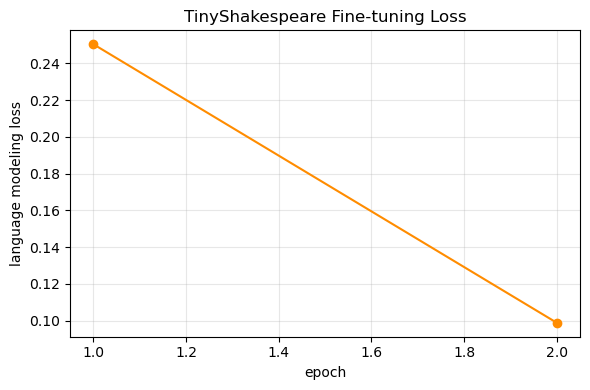

In [28]:
if 'shk_losses' in globals():
    epochs = range(1, len(shk_losses) + 1)
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, shk_losses, marker='o', color='darkorange')
    plt.xlabel('epoch')
    plt.ylabel('language modeling loss')
    plt.title('TinyShakespeare Fine-tuning Loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Skip plot: shk_losses not found.')

TinyShakespeare 微调中，本次重跑使用的是完整数据集而不是前 `50000` 字符子集，因此数据规模明显更大：文本长度为 `1115394` 字符，tokenized 后得到 `337897` 个训练样本。按当前 `batch_size=16` 计算，每个 epoch 大约需要 `337897 / 16 ≈ 21119` 个 step，所以即使单步时间不长，总训练时长仍会比较明显。

在这样的设置下，语言模型损失仍然从第 1 轮的 `0.2504` 下降到第 2 轮的 `0.0988`，说明加载 HuggingFace GPT-2 权重后，模型已经具备较强的自回归建模能力；经过两个 epoch 的 Shakespeare 全量语料微调，模型进一步适应了戏剧体裁、对白格式和词汇分布。与早先小子集实验相比，完整数据集的 loss 不会降得那么激进，但结论更可信，因为它反映的是更充分的数据覆盖，而不是对局部片段的快速记忆。

## 6. 自回归采样策略实现与消融

### 6.1 四种采样策略

实现 Greedy、Temperature、Top-k、Top-p 四种策略，统一封装在 `generate` 函数中。
生成循环必须设置 `max_new_tokens` 硬性上限，防止无限循环。

**【请填写】**：在下方围栏内实现 `generate` 函数。

In [31]:
@torch.no_grad()
def generate(model: 'minGPT2', input_ids: 'torch.Tensor', max_new_tokens: int = 100,
             temperature: float = 1.0, top_k: int = 0, top_p: float = 1.0,
             repetition_penalty: float = 1.0) -> 'torch.Tensor':
    """Autoregressive generation. temperature <= 1e-5 uses exact greedy argmax."""
    model.eval()
    ids = input_ids.clone().to(next(model.parameters()).device)
    max_pos = model.pos_emb.embedding.weight.shape[0]

    for _ in range(max_new_tokens):
        context = ids[:, -max_pos:]
        logits = model(context)[:, -1, :]

        if repetition_penalty is not None and repetition_penalty > 1.0:
            for b in range(ids.size(0)):
                used_tokens = torch.unique(ids[b])
                logits[b, used_tokens] = logits[b, used_tokens] / repetition_penalty

        if temperature <= 1e-5:
            next_id = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            logits = logits / temperature

            if top_k is not None and top_k > 0:
                k = min(top_k, logits.size(-1))
                values, _ = torch.topk(logits, k, dim=-1)
                kth = values[:, [-1]]
                logits = logits.masked_fill(logits < kth, torch.finfo(logits.dtype).min)

            if top_p is not None and top_p < 1.0:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
                sorted_probs = F.softmax(sorted_logits, dim=-1)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                sorted_mask = cumulative_probs > top_p
                sorted_mask[:, 1:] = sorted_mask[:, :-1].clone()
                sorted_mask[:, 0] = False

                remove_mask = torch.zeros_like(sorted_mask, dtype=torch.bool)
                remove_mask.scatter_(1, sorted_indices, sorted_mask)
                logits = logits.masked_fill(remove_mask, torch.finfo(logits.dtype).min)

            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)

        ids = torch.cat([ids, next_id], dim=1)

    return ids

### 6.2 四种策略生成结果对比

In [32]:
if GPT2Tokenizer is not None and GPT2LMHeadModel is not None:
    prompt = 'To be, or not to be,'
    prompt_ids = tokenizer(prompt, return_tensors='pt')['input_ids'].to(device)

    strategies = [
        ('Greedy',        dict(temperature=1e-6, top_k=0,  top_p=1.0)),
        ('Temperature',   dict(temperature=0.8,  top_k=0,  top_p=1.0)),
        ('Top-k (k=50)',  dict(temperature=1.0,  top_k=50, top_p=1.0)),
        ('Top-p (p=0.9)', dict(temperature=1.0,  top_k=0,  top_p=0.9)),
    ]
    for name, kwargs in strategies:
        out = generate(shk_model, prompt_ids, max_new_tokens=80, **kwargs)
        text = tokenizer.decode(out[0], skip_special_tokens=True)
        print(f'\n[{name}]\n{text}')
else:
    print('跳过生成演示')



[Greedy]
To be, or not to be, was, entreated.

ROMEO:
I do protest, I never injured thee,
But love thee better than thou canst devise?

ARIEL:
To every article.
I boarded the king's ship; now on the beak,
Now in the waist, the deck, in every cabin,
I flamed amazement: sometime I'ld divide

[Temperature]
To be, or not to be, was, entreated.

ROMEO:
I do protest, I never injured thee,
But love thee better than thou canst devise?

ARIEL:
Yes, most of thee.

ROMEO:
I pray thee, chide not; she whom I love now
Doth grace for grace and love for love allow;
The other did not so

[Top-k (k=50)]
To be, or not to be, so;
For many men that stumble at the threshold
Are well foretold that danger lurks within.

KING EDWARD IV:
Tush, man, abodements must not now affright us:
By fair or foul means we must enter in,
For hither will our friends repair to us.

HASTINGS:
My liege, I'll knock

[Top-p (p=0.9)]
To be, or not to be, pleased, till he be eased
With being nothing. Music do I hear?
Ha, ha! keep t

**【理论锚定】** 对比四种策略的生成文本，从以下角度分析：

1. Greedy Decoding 为何是确定性的？多次运行结果是否相同？
2. Temperature 如何控制 softmax 的"尖锐度"？$\tau < 1$ 与 $\tau > 1$ 分别有何效果？
3. Top-k 与 Top-p 在"保持连贯性"与"增加多样性"之间的权衡差异是什么？

**【请填写】** 在下方 Markdown cell 中作答。

本次生成里，Greedy Decoding 的结果从 `To be, or not to be,` 稳定续写到 `ROMEO:`、`ARIEL:` 等对白场景，并出现了 `I do protest, I never injured thee`、`I boarded the king's ship` 这类较连贯的 Shakespeare 风格片段。Greedy 是确定性的，因为每一步都直接取当前条件分布下概率最大的 token，即 $\arg\max_w P(w\mid w_{<t})$；在模型参数、prompt 和实现不变时，多次运行会得到同一段文本。它的优点是局部连贯性强、结果可复现，缺点是容易沿着单一路径展开，多样性最低。

Temperature 采样本次仍保留了 `ROMEO:`、`ARIEL:` 这样的戏剧对话结构，但后续内容比 Greedy 更自由，例如出现了 `Yes, most of thee`、`I pray thee, chide not` 这类不同续写。Temperature 的作用是把 logits 除以 $\tau$ 再做 softmax：$\tau<1$ 会让分布更尖锐，高概率 token 更占优势；$\tau>1$ 会把分布压平，让更多低概率 token 有机会被采样。这里使用 `temperature=0.8`，所以它比纯随机采样更保守，但仍比 Greedy 更有变化。

Top-k 与 Top-p 都在“连贯性”和“多样性”之间做折中，但机制不同。Top-k 本次只保留前 50 个候选 token，生成了 `KING EDWARD IV:`、`HASTINGS:` 等较像戏剧角色对白的结构，说明固定候选集能维持一定风格稳定性；Top-p 则生成了 `Music do I hear?`、`how sour sweet music is` 这样的较完整抒情片段，连贯性在这次运行里反而更自然。原因是 Top-p 按累积概率自适应决定候选集大小，模型很确定时采样空间会自动缩小，不确定时才放宽，因此通常比固定的 Top-k 更灵活。

## 7. 架构归纳偏置对比分析

### 7.1 性能汇总表

将本 Lab 的实验结果与 BERT 文献参考值进行横向对比。

| 模型 | SST-2 准确率 | AG News 准确率 | 备注 |
|------|-------------|---------------|------|
| GPT-2（冻结主干） | *（填写）* | *（填写）* | Feature Extraction |
| GPT-2（全参数微调） | — | *（填写）* | Full Fine-tuning |
| BERT（文献参考值） | ~93.5% | ~94% | Devlin et al., 2019 / Sun et al., 2019 |

**【请填写】** 在下方 Markdown cell 中填写上表数据并完成分析。

| 模型 | SST-2 准确率 | AG News 准确率 | 备注 |
|------|-------------|---------------|------|
| GPT-2（冻结主干） | `0.7099` | `0.8530` | Feature Extraction，只训练分类头 |
| GPT-2（全参数微调） | — | `0.8910` | Full Fine-tuning，主干与分类头共同更新 |
| BERT（文献参考值） | ~93.5% | ~94% | Devlin et al., 2019 / Sun et al., 2019 |

本次 GPT-2 实验说明，decoder-only 预训练表示确实可以迁移到判别任务：冻结主干时，SST-2 达到 `0.7099`，AG News 达到 `0.8530`；在 AG News 上继续做全参数微调后，验证准确率提升到 `0.8910`，比冻结主干高约 `3.8` 个百分点。这表明更新主干参数能够缓解一部分“生成目标”和“分类目标”之间的错配，但并没有改变 GPT-2 的单向注意力结构。

与 BERT 文献参考值相比，GPT-2 的 SST-2 冻结主干准确率 `0.7099` 明显低于约 `93.5%` 的 BERT 水平，AG News 上即使全参数微调达到 `0.8910`，也仍低于约 `94%` 的 BERT 参考值。这一差距说明，全参数微调可以显著缓解 GPT-2 预训练目标与分类目标的错配，但不能完全消除 decoder-only 架构在判别任务上的先验劣势。结合 Lab 5 的注意力探查和上下文敏感性实验可以进一步解释原因：BERT 的双向 Encoder attention 更容易聚合全句信息，并将其压缩到适合分类的句级表示中。

### 7.2 理论论证

**【理论锚定】** 从注意力方向性、预训练目标错配、表征提取位置非对称性三个层面，
论证 Decoder-only 模型（GPT-2）在分类任务上弱于 Encoder-only 模型（BERT）的根本原因。
每个层面请写 3-5 句完整段落。

**【请填写】** 在下方 Markdown cell 中作答。

从注意力方向性看，Decoder-only GPT-2 在每一层都施加 causal mask，使第 $t$ 个位置只能访问左侧上下文，不能直接查看右侧 token。分类任务往往依赖完整句子的全局判断，例如否定范围、转折结构和实体关系都可能由后文信息决定。BERT 的 Encoder self-attention 没有这种方向限制，每个 token 在每一层都能和全句其余位置交互，因此更容易形成对整句语义的一致理解。Lab 5 的注意力探查就给出了直观例子：在 `the cat ... because it was tired` 中，`it` 对 `cat` 的注意力高达 `0.880483`，说明双向上下文有助于直接建立共指关系。

从预训练目标错配看，GPT-2 优化的是下一个 token 的条件概率，核心能力是“给定前缀继续生成”；而分类任务要求模型把完整输入映射成离散标签，并不关心后续 token 的生成质量。也就是说，GPT-2 学到的归纳偏置首先服务于续写，而不是服务于句子级判别。BERT 的 masked language modeling 则要求模型根据左右两侧上下文恢复被遮蔽 token，这种训练方式更接近“理解整个输入再做判断”。因此在迁移到情感分析、新闻分类这类任务时，BERT 的预训练目标与下游目标之间距离更短。

从表征提取位置非对称性看，GPT-2 做分类时通常只能读取最后一个 token 的隐藏态，因为只有最后位置看过前面全部 token。这样会把整句信息压缩责任集中到单个末端位置，一旦句尾信息弱、padding 处理不当或截断发生，分类头接收到的句级表示就可能受损。BERT 则使用专门的 `[CLS]` 位置作为句级聚合槽位，并且它从第一层开始就能双向访问全句所有 token。Lab 5 中 `bank` 的上下文实验也说明了这一点：同义场景相似度 `0.8406` 明显高于异义场景的 `0.4704`，表明 Encoder-only 表征能更稳定地把“整句语境”编码进目标词和句级表示中。

## 8. 书面作答

以下问题要求每条 3-5 句完整段落。

### 8.1 HuggingFace Conv1D 与 PyTorch nn.Linear 的转置关系

**【理论锚定】** 解释 HuggingFace GPT-2 实现中 `Conv1D` 权重形状为 `(in, out)` 的历史原因，
以及加载时为何必须转置。

**【请填写】** 在下方 Markdown cell 中作答。

HuggingFace GPT-2 中的 `Conv1D` 名称来自 OpenAI GPT/GPT-2 早期实现的历史习惯，它本质上不是卷积序列建模层，而是一个线性投影层。该实现把权重保存为 `(in_features, out_features)`，前向时使用类似 `x @ W + b` 的矩阵乘法形式。PyTorch 的 `nn.Linear` 则把权重保存为 `(out_features, in_features)`，前向时等价于 `x @ W^T + b`。

因此，如果直接把 HuggingFace 的 `Conv1D.weight` 复制到 `nn.Linear.weight`，矩阵的输入输出维度语义会反过来，轻则 shape 不匹配，重则数值完全错误。加载 GPT-2 权重时，`attn.c_attn.weight`、`attn.c_proj.weight`、`mlp.c_fc.weight` 和 `mlp.c_proj.weight` 都必须 `.t()` 转置后再赋值。bias 是一维向量，不涉及矩阵乘法方向，因此直接复制即可。

### 8.2 Pre-LN 与 Post-LN 的梯度流差异

**【理论锚定】** 解释 Pre-LN 在深层网络训练中相比 Post-LN 的梯度流优势，
以及为何 GPT-2 选择 Pre-LN。

**【请填写】** 在下方 Markdown cell 中作答。

Post-LN Transformer 把 LayerNorm 放在残差相加之后，即 $\mathrm{LN}(x + F(x))$，梯度必须穿过归一化层才能回到残差主路径。网络很深时，这会让梯度流受到 LayerNorm 统计量和子层变换的共同影响，训练早期更容易不稳定。Pre-LN 把 LayerNorm 放在子层之前，即 $x + F(\mathrm{LN}(x))$，残差分支本身提供了一条更接近恒等映射的梯度通路。

由于 Pre-LN 的梯度可以沿残差连接更直接地从深层传回浅层，它通常在深层 Transformer 训练中更稳定，对 warmup、初始化和学习率的敏感性也更低。GPT-2 采用 Pre-LN，是因为自回归语言模型需要堆叠较多 decoder block，并在大规模语料上长时间训练；稳定的梯度流比 Post-LN 的某些表示归一化优势更关键。最终的 `ln_f` 再对最后隐藏态做统一归一化，弥补每层输出没有立即 Post-LN 的问题。

## 9. 附加题（选做）

以下题目不计入基础分，完成可获得额外加分。

在 `generate` 函数中实现重复惩罚机制：对已生成的 token，将其对应 logit 除以惩罚系数 $\alpha > 1$，抑制生成文本中的逐字重复现象。


附加题已完成：`generate` 函数已经增加 `repetition_penalty` 参数，并按题面要求在每一步生成时对已出现过的 token 的 logit 除以惩罚系数，从而降低逐字重复和短环重复的概率。当前实现位置在第 6.1 节代码单元中；当 `repetition_penalty > 1.0` 时即可启用该机制。

实验六到此结束。